In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
cf = pd.read_csv(r"C:\Users\priya\Desktop\PyCh_Pro\Churn_Analysis_and_Modelling\data\raw\telco_churn.csv")

In [4]:
cf.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
cf.shape

(7043, 21)

In [6]:
cf.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4514,3956-MGXOG,Female,0,No,No,28,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,80.60,2244.95,No
5109,7113-HIPFI,Male,0,Yes,Yes,66,Yes,No,DSL,Yes,...,Yes,Yes,No,No,Two year,No,Mailed check,65.85,4097.05,No
5116,4759-TRPLW,Male,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,70.40,70.4,Yes
689,5076-YVXCM,Male,0,No,No,51,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),83.40,4149.45,No
5661,4396-KLSEH,Male,0,No,No,4,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.85,63,No


In [7]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
cf['TotalCharges'] = pd.to_numeric(cf['TotalCharges'], errors='coerce')

In [9]:
cf.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
features = list(cf.columns)
features

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [11]:
num_features = cf.select_dtypes(include=['int64', 'float64']).columns
cat_features = cf.select_dtypes(include=['object', 'category']).columns

### Univariate Analysis

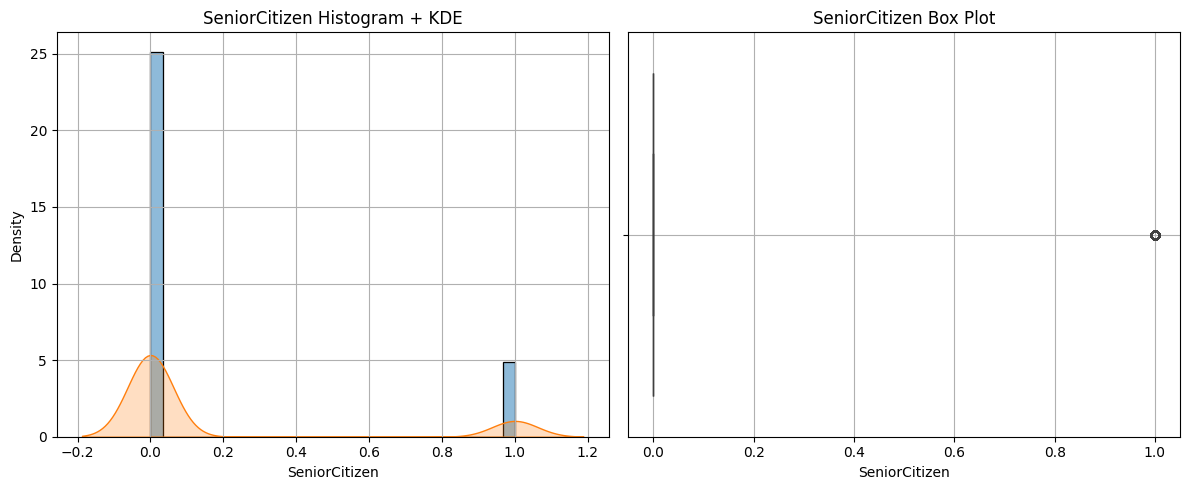

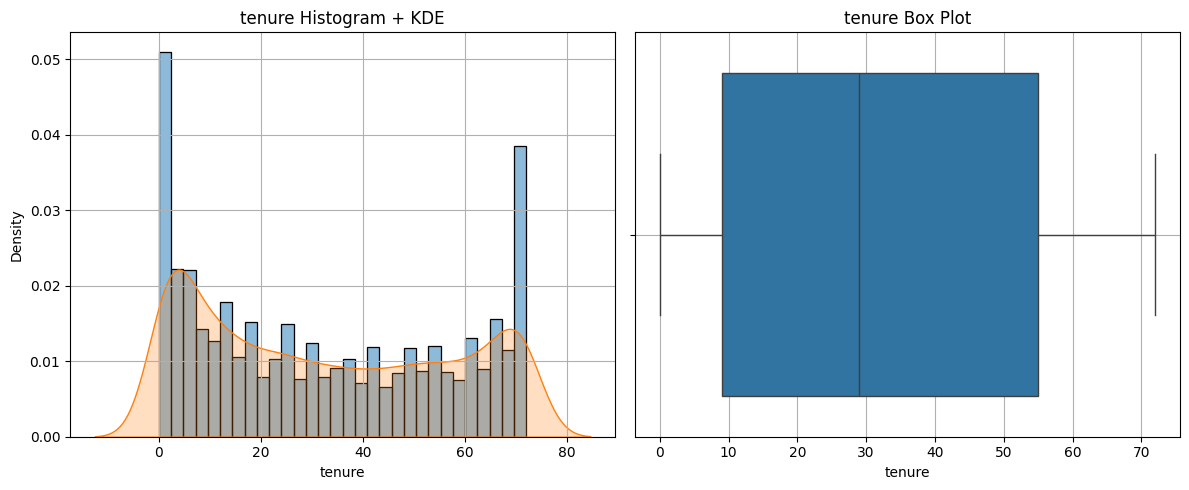

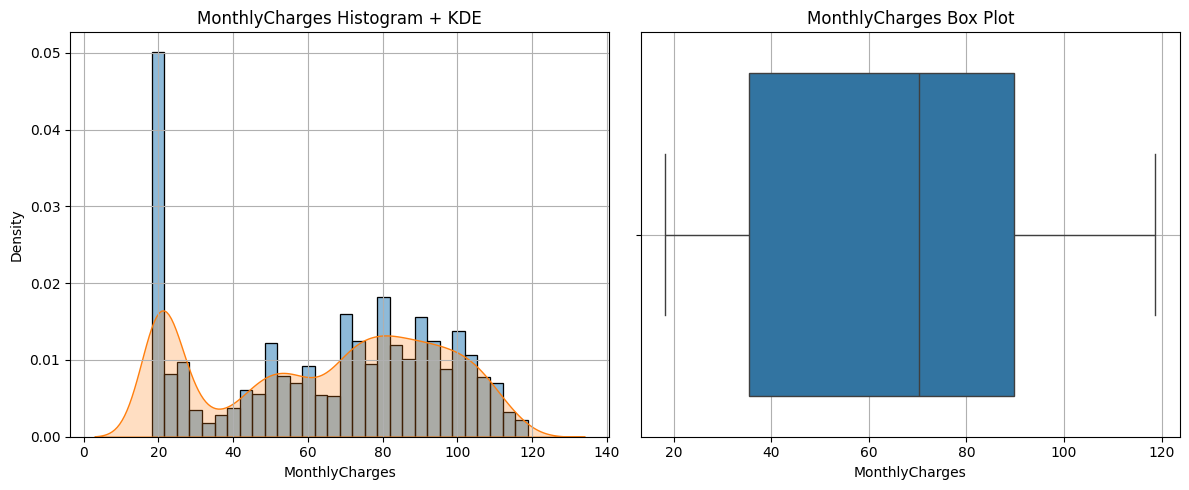

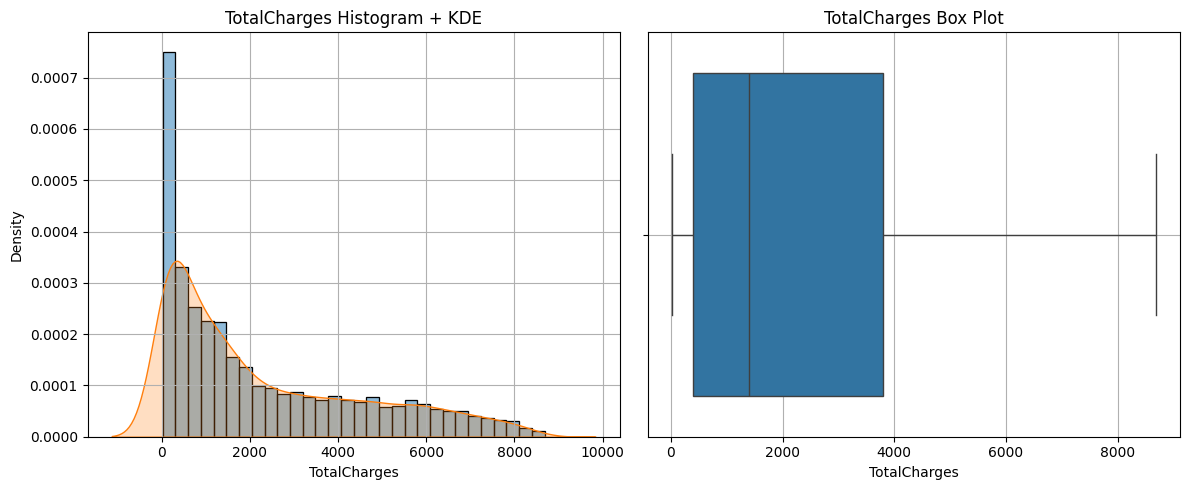

In [12]:
for i in num_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram + KDE on same axis
    sns.histplot(cf[i], bins=30, stat='density', ax=axes[0], alpha=0.5)
    sns.kdeplot(cf[i], fill=True, ax=axes[0])
    
    axes[0].set_title(f"{i} Histogram + KDE")
    axes[0].grid(True)

    # Boxplot unchanged
    sns.boxplot(x=cf[i], ax=axes[1])
    axes[1].set_title(f"{i} Box Plot")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    

In [13]:
cf["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

<Axes: xlabel='SeniorCitizen'>

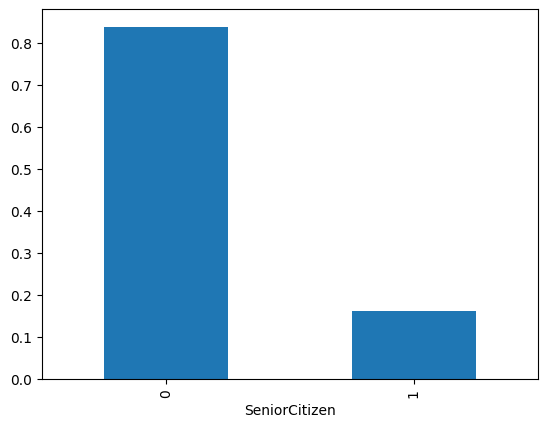

In [14]:
cf["SeniorCitizen"].value_counts(normalize=True).plot(kind="bar")

In [15]:
cf.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
cf.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

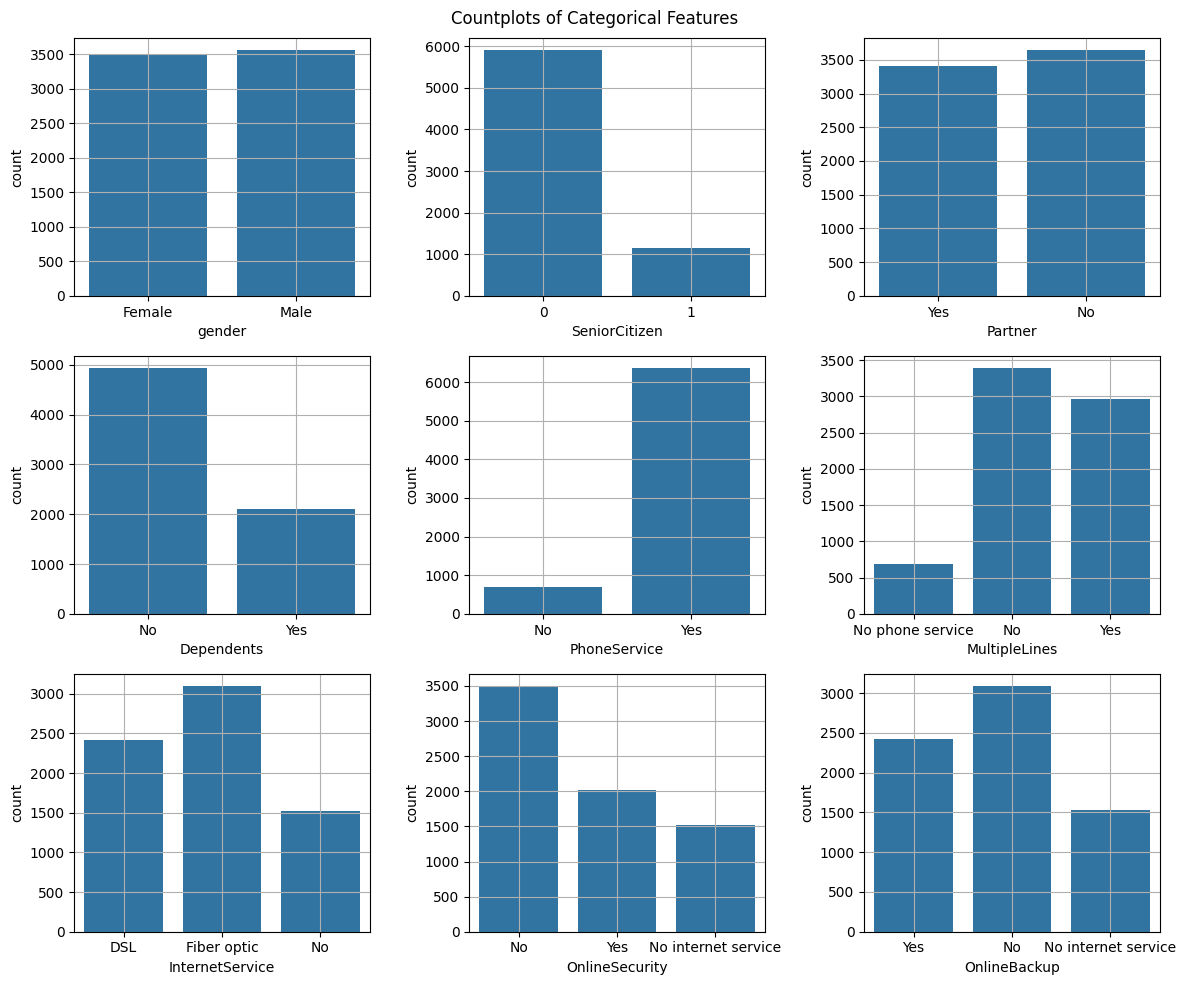

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

sns.countplot(x="gender", data=cf, ax=axes[0, 0])
axes[0, 0].grid(True)

sns.countplot(x="SeniorCitizen", data=cf, ax=axes[0, 1])
axes[0, 1].grid(True)

sns.countplot(x="Partner", data=cf, ax=axes[0, 2])
axes[0, 2].grid(True)

sns.countplot(x="Dependents", data=cf, ax=axes[1, 0])
axes[1, 0].grid(True)

sns.countplot(x="PhoneService", data=cf, ax=axes[1, 1])
axes[1, 1].grid(True)

sns.countplot(x="MultipleLines", data=cf, ax=axes[1, 2])
axes[1, 2].grid(True)

sns.countplot(x = "InternetService", data = cf, ax = axes[2, 0])
axes[2, 0].grid(True)

sns.countplot(x = "OnlineSecurity", data = cf, ax = axes[2, 1])
axes[2, 1].grid(True)

sns.countplot(x = "OnlineBackup", data = cf, ax = axes[2, 2])
axes[2, 2].grid(True)

fig.suptitle("Countplots of Categorical Features")

plt.tight_layout()
plt.show()

In [18]:
cf.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

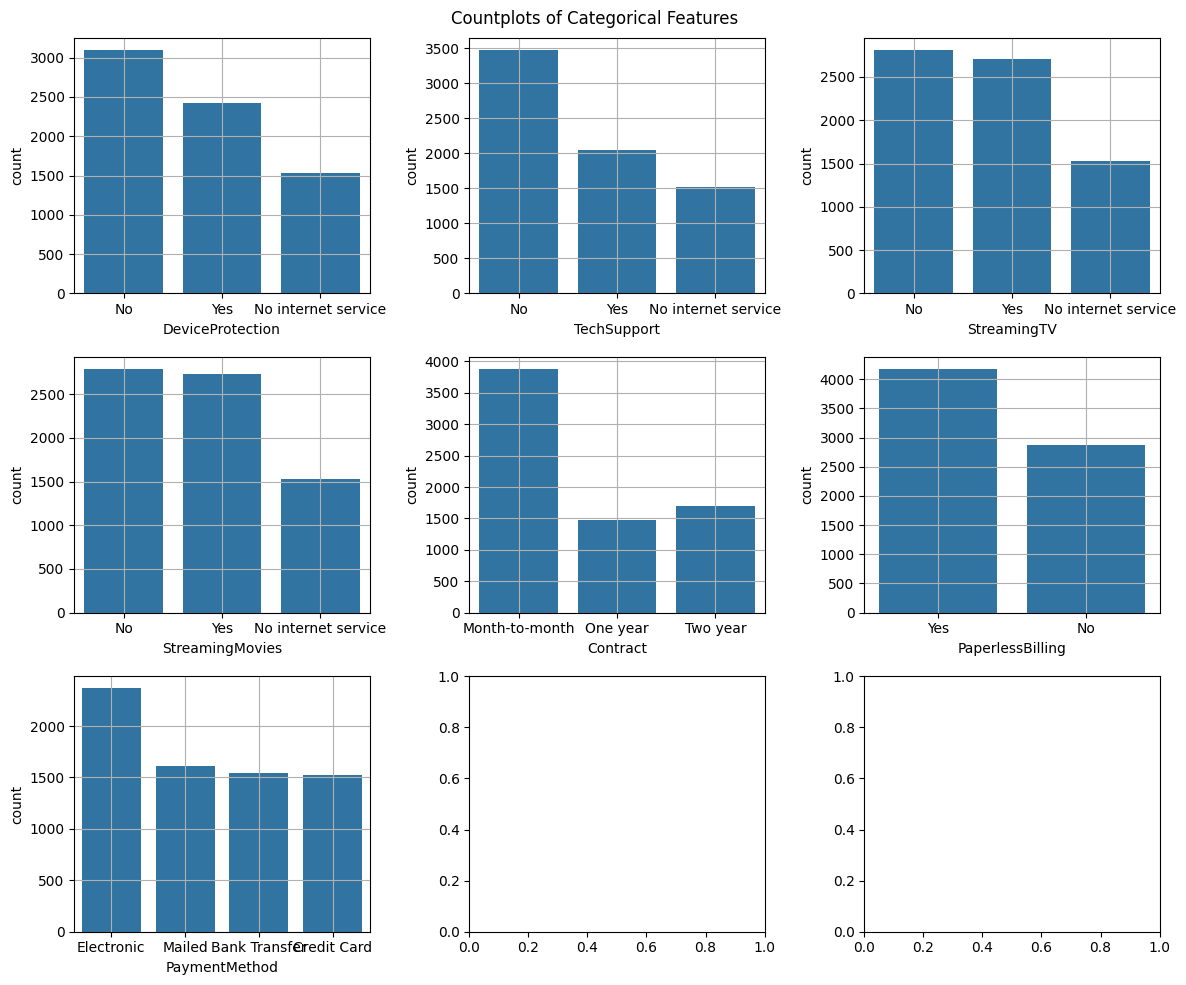

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

sns.countplot(x = "DeviceProtection", data = cf, ax = axes[0,0])
axes[0,0].grid(True)

sns.countplot(x = "TechSupport", data = cf, ax = axes[0,1])
axes[0,1].grid(True)

sns.countplot(x = "StreamingTV", data = cf, ax = axes[0,2])
axes[0,2].grid(True)

sns.countplot(x = "StreamingMovies", data = cf, ax = axes[1, 0])
axes[1,0].grid(True)

sns.countplot(x = "Contract", data = cf, ax = axes[1,1])
axes[1,1].grid(True)

sns.countplot(x = "PaperlessBilling", data = cf, ax = axes[1, 2])
axes[1,2].grid(True)

cf['PaymentMethod'] = cf['PaymentMethod'].replace({
    'Electronic check': 'Electronic',
    'Mailed check': 'Mailed',
    'Bank transfer (automatic)': 'Bank Transfer',
    'Credit card (automatic)': 'Credit Card'
})

sns.countplot(x = "PaymentMethod", data = cf, ax = axes[2, 0])
axes[2,0].grid(True)

fig.suptitle("Countplots of Categorical Features")

plt.tight_layout()
plt.show()

In [20]:
cf["PaymentMethod"].value_counts()

PaymentMethod
Electronic       2365
Mailed           1612
Bank Transfer    1544
Credit Card      1522
Name: count, dtype: int64

### Multivariate Analysis

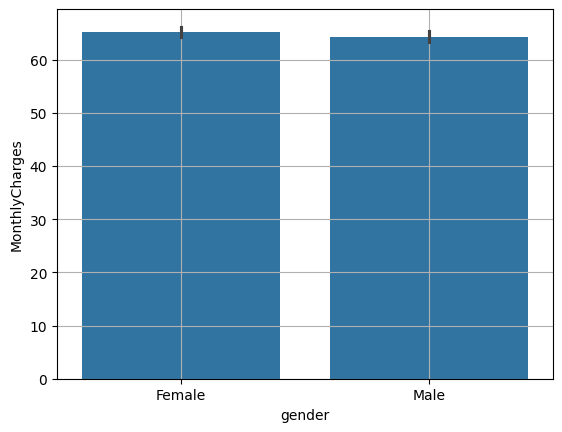

In [21]:
sns.barplot(x = "gender", y = "MonthlyCharges", data = cf)
plt.grid(True)

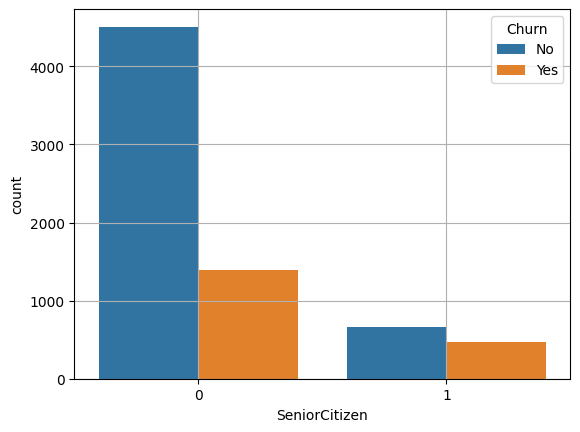

In [22]:
sns.countplot(x = "SeniorCitizen", data = cf, hue = "Churn")
plt.grid(True)

In [23]:
cf.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [24]:
cf.groupby('Contract')['Churn'].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [25]:
pd.crosstab(cf['Contract'], cf['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


<Axes: xlabel='Contract'>

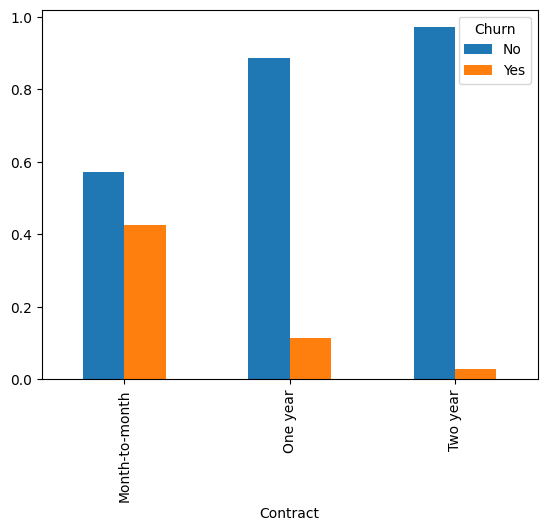

In [26]:
pd.crosstab(cf['Contract'], cf['Churn'], normalize='index').plot(kind='bar')

In [27]:
cf.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank Transfer,42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic,70.70,151.65,Yes


<Axes: xlabel='gender'>

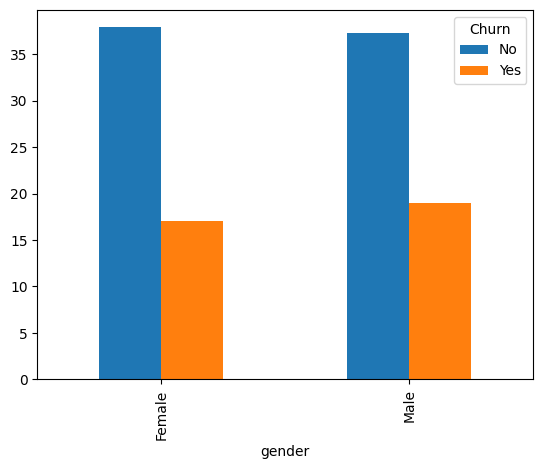

In [28]:
pd.pivot_table(cf, values = "tenure", index = "gender", columns = "Churn", aggfunc="mean").plot(kind = "bar")
# obvious metric, churn customer from both gender have lower tenure

<Axes: xlabel='PaymentMethod'>

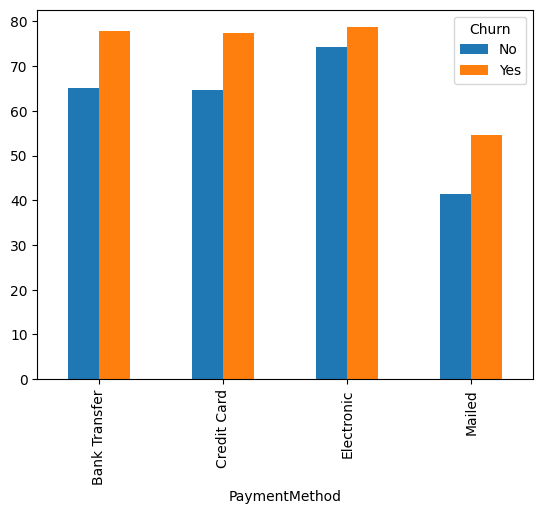

In [29]:
pd.pivot_table(cf, values = "MonthlyCharges", index = "PaymentMethod", columns = "Churn").plot(kind = "bar")

In [30]:
pd.crosstab(cf["PaymentMethod"], cf["Churn"], normalize = "index")

Churn,No,Yes
PaymentMethod,,
Bank Transfer,0.832902,0.167098
Credit Card,0.847569,0.152431
Electronic,0.547146,0.452854
Mailed,0.808933,0.191067


In [31]:
pd.crosstab(cf['PaymentMethod'], cf['SeniorCitizen'], normalize='index')

SeniorCitizen,0,1
PaymentMethod,,
Bank Transfer,0.849093,0.150907
Credit Card,0.854796,0.145204
Electronic,0.748837,0.251163
Mailed,0.941687,0.058313


In [32]:
mailed = cf[cf['PaymentMethod'] == 'Mailed']

pd.crosstab(mailed['SeniorCitizen'], mailed['Churn'], normalize='index')

Churn,No,Yes
SeniorCitizen,,
0,0.826087,0.173913
1,0.531915,0.468085


In [33]:
pd.crosstab([cf["SeniorCitizen"],cf["Contract"]], cf["Churn"], normalize = "index")*100
# senior with per month contract are one of the worst for a telecom, according to this data

Churn                                No        Yes
SeniorCitizen Contract                            
0             Month-to-month  60.430248  39.569752
              One year        89.321902  10.678098
              Two year        97.290323   2.709677
1             Month-to-month  45.353160  54.646840
              One year        84.736842  15.263158
              Two year        95.862069   4.137931

<Axes: xlabel='SeniorCitizen'>

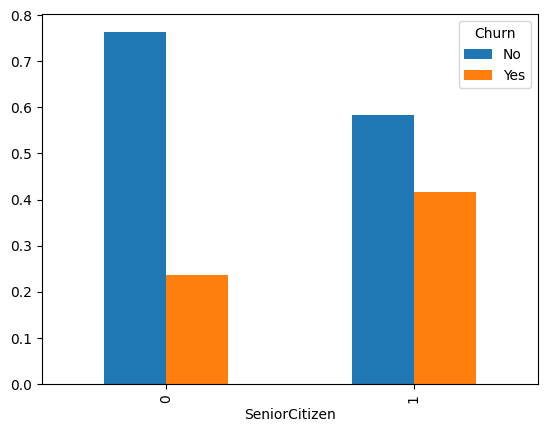

In [34]:
pd.crosstab(cf["SeniorCitizen"], cf["Churn"], normalize = "index").plot(kind = "bar")

In [35]:
pd.pivot_table(cf, values = "MonthlyCharges", index = "PaperlessBilling", columns = "Churn")

Churn,No,Yes
PaperlessBilling,,
No,49.813962,63.157463
Yes,71.195525,78.221429


Churn,No,Yes
Dependents,,
No,0.687209,0.312791
Yes,0.845498,0.154502


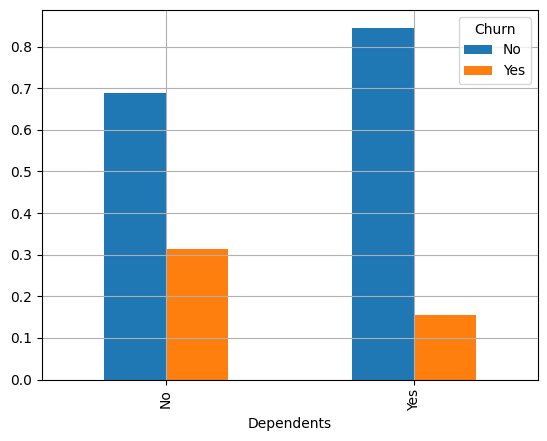

In [36]:
pd.crosstab(cf["Dependents"], cf["Churn"], normalize = "index").plot(kind = "bar")
plt.grid(True)
pd.crosstab(cf["Dependents"], cf["Churn"], normalize = "index")

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


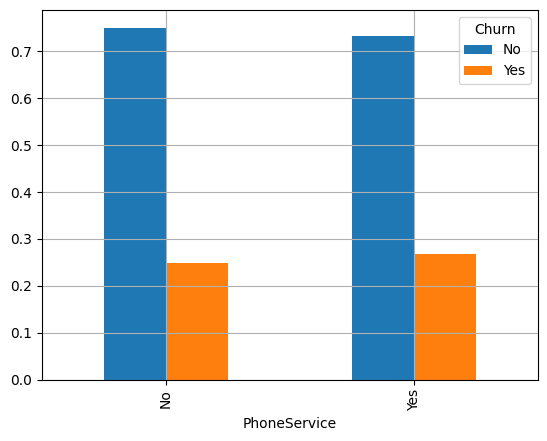

In [37]:
pd.crosstab(cf["PhoneService"], cf["Churn"], normalize = "index").plot(kind = "bar")
plt.grid(True)
pd.crosstab(cf["PhoneService"], cf["Churn"], normalize = "index")*100

In [38]:
pd.crosstab(cf["StreamingTV"], cf["Churn"])

Churn,No,Yes
StreamingTV,,
No,1868,942
No internet service,1413,113
Yes,1893,814


In [39]:
pd.crosstab(cf["InternetService"], cf["OnlineSecurity"])

OnlineSecurity,No,No internet service,Yes
InternetService,,,
DSL,1241,0,1180
Fiber optic,2257,0,839
No,0,1526,0


In [40]:
pd.crosstab([cf['Contract'], cf['PaymentMethod']],
            cf['Churn'], normalize='index') 
#electronic is the worst when contract is for month only

Churn                               No       Yes
Contract       PaymentMethod                    
Month-to-month Bank Transfer  0.658744  0.341256
               Credit Card    0.672192  0.327808
               Electronic     0.462703  0.537297
               Mailed         0.684211  0.315789
One year       Bank Transfer  0.902813  0.097187
               Credit Card    0.896985  0.103015
               Electronic     0.815562  0.184438
               Mailed         0.931751  0.068249
Two year       Bank Transfer  0.966312  0.033688
               Credit Card    0.977625  0.022375
               Electronic     0.922619  0.077381
               Mailed         0.992147  0.007853

In [41]:
pd.pivot_table(cf,
               values='tenure',
               index='Contract',
               columns='Churn',
               aggfunc='mean')

Churn,No,Yes
Contract,,
Month-to-month,21.033333,14.016918
One year,41.674063,44.963855
Two year,56.602914,61.270833


In [42]:
services = ['OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

cf['TotalServices'] = (cf[services] == 'Yes').sum(axis=1)

pd.crosstab(cf['TotalServices'], cf['Churn'], normalize='index')

Churn,No,Yes
TotalServices,,
0,0.785940,0.214060
1,0.542443,0.457557
2,0.641820,0.358180
3,0.726297,0.273703
4,0.776995,0.223005
5,0.875657,0.124343
6,0.947183,0.052817


In [43]:
cf.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TotalServices'],
      dtype='object')

In [44]:
pd.pivot_table(cf, values = "MonthlyCharges", index = "InternetService", columns = "Churn")

Churn,No,Yes
InternetService,,
DSL,60.212105,49.083224
Fiber optic,93.932379,88.126484
No,21.136058,20.368142


Churn,No,Yes
Partner,,
No,28.362966,13.176667
Yes,45.793267,26.593423


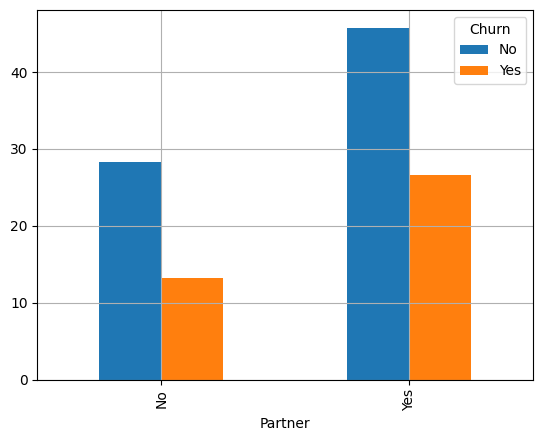

In [45]:
pd.pivot_table(cf, values = "tenure", index = "Partner", columns = "Churn").plot(kind = "bar")
plt.grid(True)
pd.pivot_table(cf, values = "tenure", index = "Partner", columns = "Churn")

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


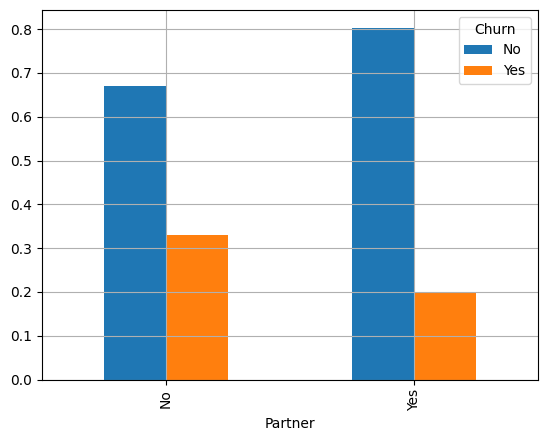

In [46]:
pd.crosstab(cf['Partner'], cf['Churn'], normalize='index').plot(kind = "bar")
plt.grid(True)
pd.crosstab(cf['Partner'], cf['Churn'], normalize='index')*100

In [47]:
pd.pivot_table(cf,
               values='TotalCharges',
               index='Contract',
               columns='Churn',
               aggfunc='mean')

Churn,No,Yes
Contract,,
Month-to-month,1521.927590,1164.460574
One year,2903.569908,4066.212048
Two year,3678.986103,5432.363542


In [48]:
cf.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TotalServices'],
      dtype='object')

<Axes: >

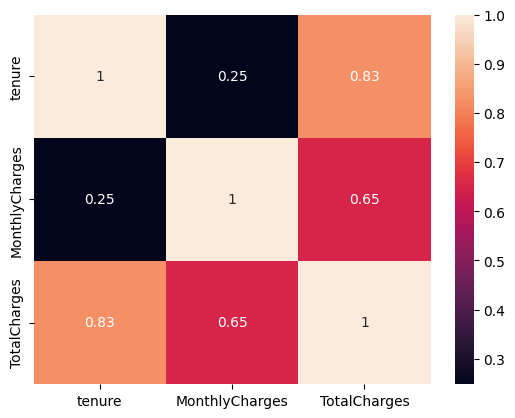

In [56]:
num_cf = cf[["tenure", "MonthlyCharges", "TotalCharges"]]
x = num_cf.corr()
sns.heatmap(x, annot = True)